In [1]:
begin
    using Pkg
    Pkg.activate(joinpath(@__DIR__, "../Examples/"))
end
Threads.nthreads()
using LinearAlgebra
using SparseArrays
using GLMakie
using Revise
using BindingAndCatalysis

  Activating project at `~/Realizibility_index/BindingAndCatalysis.jl/Examples`


In [2]:
model = let
    x_sym = [
        :I, :A, :Astar, :B, :Bstar, :E,
        :C1, :C2, :C3, :C4,
    ]

    q_sym = [
        :tI, 
        :tA, :tAstar,
        :tB, :tBstar, :tE,
    ]

    K_sym = [
        :KA1, :KA2, :KB1, :KB2,
    ]

    # Binding equilibria:
    # KA1: I + A      <-> C1
    # KA2: Bstar + Astar <-> C2
    # KB1: Astar + B <-> C3
    # KB2: E + Bstar <-> C4
    N = [
        # :I, :A, :Astar, :B, :Bstar, :E, :C1, :C2, :C3, :C4,
        1 1 0 0 0 0 -1  0  0  0
        0 0 1 0 1 0  0 -1  0  0
        0 0 1 1 0 0  0  0 -1  0
        0 0 0 0 1 1  0  0  0 -1
    ]

    Bnc(N=N, x_sym=x_sym, q_sym=q_sym, K_sym=K_sym)
end

let
    # Fluxes:
    # v1 = kA1 * C1 : A -> Astar
    # v2 = kA2 * C2 : Astar -> A
    # v3 = kB1 * C3 : B -> Bstar
    # v4 = kB2 * C4 : Bstar -> B
    Π = diagm(ones(Int, 4))

    Γ = [
        1  -1  0  0   # tA
         -1 1  0  0   # tAstar
         0  0 1  -1   # tB
         0  0  -1 1   # tBstar
    ]

    update_catalysis!(
        model;
        Π=Π,
        Γ=Γ,
        x_picked=[:C1, :C2, :C3, :C4],
        q_picked=[:tAstar, :tA, :tBstar, :tB],
        w_sym=[:tAtotal, :tBtotal],
        k_sym=[:kA1, :kA2, :kB1, :kB2],
    )
end


[ Info: q is reordered to make catalysis-involving species first
[ Info: New conservation forms as catalysis involves
[ Info: tAtotal = tAstar + tA
[ Info: tBtotal = tBstar + tB


In [3]:
show_cat_dynamics(model)

6-element Vector{Symbolics.Equation}:
 Differential(t, 1)(tAstar) ~ C1*kA1 - C2*kA2
 Differential(t, 1)(tBstar) ~ C3*kB1 - C4*kB2
 Differential(t, 1)(tAtotal) ~ 0
 Differential(t, 1)(tBtotal) ~ 0
 Differential(t, 1)(tI) ~ 0
 Differential(t, 1)(tE) ~ 0

In [14]:
show_conservation(model)

6-element Vector{Symbolics.Equation}:
 tAstar ~ Astar + C2 + C3
 tBstar ~ Bstar + C2 + C4
 tAtotal ~ A + Astar + C1 + C2 + C3
 tBtotal ~ B + Bstar + C2 + C3 + C4
 tI ~ C1 + I
 tE ~ C4 + E

In [16]:
n_bnc_regimes(model)

276

In [15]:
rgms = get_bnc_regimes(model; singular=false)

122-element Vector{BindingAndCatalysis.BncRegime}:
 BncRegime(bind=[3, 5, 2, 4, 1, 6], cat=[1, 3, 2, 4], ss=([3, 5, 2, 4, 1, 6], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[3, 5, 2, 4, 1, 10], cat=[1, 3, 2, 4], ss=([3, 5, 2, 4, 1, 10], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[3, 5, 2, 4, 7, 6], cat=[1, 3, 2, 4], ss=([3, 5, 2, 4, 7, 6], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[3, 5, 2, 4, 7, 10], cat=[1, 3, 2, 4], ss=([3, 5, 2, 4, 7, 10], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[3, 8, 2, 4, 1, 6], cat=[1, 3, 2, 4], ss=([3, 8, 2, 4, 1, 6], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[3, 8, 2, 4, 1, 10], cat=[1, 3, 2, 4], ss=([3, 8, 2, 4, 1, 10], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[3, 8, 2, 4, 7, 6], cat=[1, 3, 2, 4], ss=([3, 8, 2, 4, 7, 6], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[3, 8, 2, 4, 7, 10], cat=[1, 3, 2, 4], ss=([3, 8, 2, 4, 7, 10], [1, 3, 2, 4]), n

In [5]:
get_volumes(rgms)

[ Info: Number of polyhedra to calc volume: 122
[ Info: Reached time limit (120.03 s). Stopping.


122-element Vector{BindingAndCatalysis.Volume}:
 Volume(Mean=2.097e-02, STD=1.047e-04, RelError=0.50%)
 Volume(Mean=6.288e-04, STD=3.389e-06, RelError=0.54%)
 Volume(Mean=1.189e-02, STD=5.938e-05, RelError=0.50%)
 Volume(Mean=6.998e-04, STD=3.575e-06, RelError=0.51%)
 Volume(Mean=3.912e-03, STD=1.954e-05, RelError=0.50%)
 Volume(Mean=3.400e-05, STD=7.881e-07, RelError=2.32%)
 Volume(Mean=6.983e-03, STD=3.488e-05, RelError=0.50%)
 Volume(Mean=1.366e-04, STD=1.580e-06, RelError=1.16%)
 Volume(Mean=1.352e-02, STD=6.734e-05, RelError=0.50%)
 Volume(Mean=3.524e-04, STD=2.537e-06, RelError=0.72%)
 Volume(Mean=9.729e-03, STD=4.855e-05, RelError=0.50%)
 Volume(Mean=4.731e-04, STD=2.940e-06, RelError=0.62%)
 Volume(Mean=5.556e-03, STD=2.773e-05, RelError=0.50%)
 ⋮
 Volume(Mean=5.233e-03, STD=2.613e-05, RelError=0.50%)
 Volume(Mean=3.640e-03, STD=1.819e-05, RelError=0.50%)
 Volume(Mean=4.157e-03, STD=2.076e-05, RelError=0.50%)
 Volume(Mean=8.193e-04, STD=4.095e-06, RelError=0.50%)
 Volume(Mean=1

In [6]:
sum(get_volumes(rgms))

Volume(Mean=9.996e-01, STD=1.071e-03, RelError=0.11%)

In [13]:
stable_rgms

116-element Vector{BindingAndCatalysis.BncRegime}:
 BncRegime(bind=[3, 5, 2, 4, 1, 6], cat=[1, 3, 2, 4], ss=([3, 5, 2, 4, 1, 6], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[3, 5, 2, 4, 1, 10], cat=[1, 3, 2, 4], ss=([3, 5, 2, 4, 1, 10], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[3, 5, 2, 4, 7, 6], cat=[1, 3, 2, 4], ss=([3, 5, 2, 4, 7, 6], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[3, 5, 2, 4, 7, 10], cat=[1, 3, 2, 4], ss=([3, 5, 2, 4, 7, 10], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[3, 8, 2, 4, 1, 6], cat=[1, 3, 2, 4], ss=([3, 8, 2, 4, 1, 6], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[3, 8, 2, 4, 7, 6], cat=[1, 3, 2, 4], ss=([3, 8, 2, 4, 7, 6], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[3, 10, 2, 4, 1, 6], cat=[1, 3, 2, 4], ss=([3, 10, 2, 4, 1, 6], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[3, 10, 2, 4, 1, 10], cat=[1, 3, 2, 4], ss=([3, 10, 2, 4, 1, 10], [1, 3, 2, 4]),

In [20]:
stable_rgms = filter(rgms) do rgm is_stable(rgm) end
unstable_rgms = filter(rgms) do rgm !is_stable(rgm) end
println("Stable & full dimensional regimes: $(length(stable_rgms))")
println("Unstable & full dimensional  regimes: $(length(unstable_rgms))")

Stable & full dimensional regimes: 116
Unstable & full dimensional  regimes: 6


In [21]:
sum(get_volumes(unstable_rgms))

Volume(Mean=3.884e-04, STD=2.664e-06, RelError=0.69%)

In [ ]:
sum(get_volumes(stable_rgms))

In [17]:
ss_invariant(rgm) = let 
    model =get_binding_network(rgm)
    x1 = locate_sym_x(model, :Astar)
    w1 = locate_sym_wKk(model, :tI)

    qcat = locate_sym_qcat(model, :tAstar)

    ss_invariant_Astar = let 
        H = get_H(rgm)
        abs(H[x1, w1] ) < 1e-6
    end

    ss_invariant_tAstar = let 
        F,_ = get_qcat_F_F0(rgm)
        abs(F[qcat, w1]) < 1e-6
    end

    ss_invariant_Astar, ss_invariant_tAstar
end

input_response(rgm)=let
    thresh = 0.5
    model =get_binding_network(rgm)
    bn = get_binding_regime(rgm)
    x1 = locate_sym_x(model, :C1)
    q1 = locate_sym_qK(model, :tI)
    
    qAstar = locate_sym_qK(model, :tAstar)
    xAstar = locate_sym_x(model, :Astar)

    # \log C1 / \log tI >0 
    input_response_tAstar = if is_singular(bn) 
                get_H_numerically(bn)[x1, q1] >= thresh
            else 
                get_H(bn)[x1, q1] >= thresh
            end

    # \log C1 / \log tI >0 && \log Astar / \log tAstar >0
    input_response_Astar = input_response_tAstar &&
            if is_singular(bn)
                abs(get_H_numerically(bn)[xAstar, qAstar]) >= thresh
            else 
                abs(get_H(bn)[xAstar, qAstar]) >= thresh
            end

    return input_response_Astar, input_response_tAstar
end

good_rgm_Astar = filter(stable_rgms) do rgm
    ss_invariant(rgm)[1] && input_response(rgm)[1]
end
good_rgm_tAstar = filter(stable_rgms) do rgm
    ss_invariant(rgm)[2] && input_response(rgm)[2]
end

all_rgm = union(good_rgm_Astar, good_rgm_tAstar)
length(good_rgm_Astar), length(good_rgm_tAstar)

(14, 20)

In [23]:
get_volumes([rgm for rgm in stable_rgms if !(rgm in all_rgm)]) |> sum

Volume(Mean=9.610e-01, STD=1.070e-03, RelError=0.11%)

In [24]:
for rgm in all_rgm
    if get_binding_regime(rgm) |> is_singular
        println("singular")
    else
        println("non-singular")
    end
end

non-singular
non-singular
singular
singular
non-singular
non-singular
singular
singular
singular
singular
non-singular
non-singular
singular
singular
singular
singular
singular
singular
singular
singular
singular
singular
singular
singular
singular
singular


In [31]:
rgm_Astar=[rgm for rgm in all_rgm if rgm in good_rgm_Astar && !(rgm in good_rgm_tAstar)]
rgm_tAstar=[rgm for rgm in all_rgm if !(rgm in good_rgm_Astar) && rgm in good_rgm_tAstar]
rgm_both=[rgm for rgm in all_rgm if rgm in good_rgm_Astar && rgm in good_rgm_tAstar]
println("Astar only: $(length(rgm_Astar))")
println("tAstar only: $(length(rgm_tAstar))")
println("both: $(length(rgm_both))")

Astar only: 6
tAstar only: 12
both: 8


In [32]:
sum(get_volumes(rgm_Astar))

Volume(Mean=5.281e-03, STD=1.593e-05, RelError=0.30%)

In [33]:
sum(get_volumes(rgm_both))

Volume(Mean=1.409e-02, STD=3.359e-05, RelError=0.24%)

In [34]:
sum(get_volumes(rgm_tAstar))

Volume(Mean=1.882e-02, STD=3.572e-05, RelError=0.19%)

In [119]:
show_condition(get_binding_regime(all_rgm[1])) |> print

Symbolics.Num[KA2 > tBstar, KB1 > tBtotal, KA2 > tAstar, tBstar > tE, tAtotal > tAstar, KA1 > tI, (KA2*tAtotal) > (tAstar*tBstar), (KB1*tAtotal) > (tAstar*tBtotal), tBtotal > tBstar, (KA2*tBtotal) > (tAstar*tBstar), KB1 > tAstar, tBtotal > tE, KA1 > tAtotal, tBstar > KB2]

In [117]:
let
    poly = get_polyhedron(get_binding_regime(all_rgm[1]))
    removehredundancy!(poly)
    show_condition_poly(poly;syms=qK_sym(model))
end


10-element Vector{Symbolics.Num}:
     KA2 > tBstar
    KB1 > tBtotal
     KA2 > tAstar
      tBstar > tE
 tAtotal > tAstar
         KA1 > tI
 tBtotal > tBstar
     KB1 > tAstar
    KA1 > tAtotal
     tBstar > KB2

In [107]:
Volumes[1]+ Volumes[2], Volumes[1]+ Volumes[3]

(Volume(Mean=1.434e-02, STD=3.489e-05, RelError=0.24%), Volume(Mean=1.008e-02, STD=3.134e-05, RelError=0.31%))

In [37]:
Volumes[1]+ Volumes[2], Volumes[1]+ Volumes[3]

(Volume(Mean=1.434e-02, STD=3.489e-05, RelError=0.24%), Volume(Mean=1.008e-02, STD=3.134e-05, RelError=0.31%))

In [39]:
findmax([v for (rgm,v) in rgm_both])

(Volume(Mean=4.625e-03, STD=2.312e-05, RelError=0.50%), 4)

In [40]:
bnc_rgm_max = rgm_both[findmax([v for (rgm,v) in rgm_both])[2]][1]

BncRegime
  dominant mode: bind=[9, 5, 2, 4, 7, 10], cat=[1, 3, 2, 4], ss=([9, 5, 2, 4, 7, 10], [1, 3, 2, 4])
  nullity: 0
  asymptotic: true

In [41]:
ps = get_polyhedron.(all_rgm)
M = Matrix{Int}(undef, length(all_rgm), length(all_rgm))
Threads.@threads for i in 1:length(all_rgm)
    for j in 1:length(all_rgm)
        M[i, j] = dim(intersect(ps[i], ps[j]))
    end
end

In [42]:
dim(ps[1])

12

In [43]:
sparse(M.==12)

6×6 SparseMatrixCSC{Bool, Int64} with 6 stored entries:
 1  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  1  ⋅  ⋅  ⋅  ⋅
 ⋅  ⋅  1  ⋅  ⋅  ⋅
 ⋅  ⋅  ⋅  1  ⋅  ⋅
 ⋅  ⋅  ⋅  ⋅  1  ⋅
 ⋅  ⋅  ⋅  ⋅  ⋅  1

In [44]:
using BindingAndCatalysis.Graphs
adjmat = sparse(M.==11)

6×6 SparseMatrixCSC{Bool, Int64} with 18 stored entries:
 ⋅  1  1  ⋅  1  ⋅
 1  ⋅  ⋅  1  ⋅  1
 1  ⋅  ⋅  1  1  ⋅
 ⋅  1  1  ⋅  ⋅  1
 1  ⋅  1  ⋅  ⋅  1
 ⋅  1  ⋅  1  1  ⋅

In [45]:
g = SimpleGraph(adjmat)
is_connected(g)

true

In [55]:
get_binding_regime.(all_rgm)

26-element Vector{BindingAndCatalysis.BindRegime{ExactLogExpr, Int64}}:
 BindRegime(perm=[3, 5, 2, 4, 1, 10], nullity=0, asymptotic=true)
 BindRegime(perm=[3, 5, 2, 4, 7, 10], nullity=0, asymptotic=true)
 BindRegime(perm=[3, 10, 2, 4, 1, 10], nullity=1, asymptotic=true)
 BindRegime(perm=[3, 10, 2, 4, 7, 10], nullity=1, asymptotic=true)
 BindRegime(perm=[8, 5, 2, 4, 1, 10], nullity=0, asymptotic=true)
 BindRegime(perm=[8, 5, 2, 4, 7, 10], nullity=0, asymptotic=true)
 BindRegime(perm=[8, 8, 2, 4, 1, 10], nullity=1, asymptotic=true)
 BindRegime(perm=[8, 8, 2, 4, 7, 10], nullity=1, asymptotic=true)
 BindRegime(perm=[8, 10, 2, 4, 1, 10], nullity=1, asymptotic=true)
 BindRegime(perm=[8, 10, 2, 4, 7, 10], nullity=1, asymptotic=true)
 BindRegime(perm=[9, 5, 2, 4, 1, 10], nullity=0, asymptotic=true)
 BindRegime(perm=[9, 5, 2, 4, 7, 10], nullity=0, asymptotic=true)
 BindRegime(perm=[9, 10, 2, 4, 1, 10], nullity=1, asymptotic=true)
 BindRegime(perm=[9, 10, 2, 4, 7, 10], nullity=1, asymptotic=true

In [57]:
singular_rgm = filter(all_rgm) do rgm 
    get_binding_regime(rgm) |> is_singular
end

20-element Vector{Any}:
 BncRegime(bind=[3, 10, 2, 4, 1, 10], cat=[1, 3, 2, 4], ss=([3, 10, 2, 4, 1, 10], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[3, 10, 2, 4, 7, 10], cat=[1, 3, 2, 4], ss=([3, 10, 2, 4, 7, 10], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[8, 8, 2, 4, 1, 10], cat=[1, 3, 2, 4], ss=([8, 8, 2, 4, 1, 10], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[8, 8, 2, 4, 7, 10], cat=[1, 3, 2, 4], ss=([8, 8, 2, 4, 7, 10], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[8, 10, 2, 4, 1, 10], cat=[1, 3, 2, 4], ss=([8, 10, 2, 4, 1, 10], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[8, 10, 2, 4, 7, 10], cat=[1, 3, 2, 4], ss=([8, 10, 2, 4, 7, 10], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[9, 10, 2, 4, 1, 10], cat=[1, 3, 2, 4], ss=([9, 10, 2, 4, 1, 10], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[9, 10, 2, 4, 7, 10], cat=[1, 3, 2, 4], ss=([9, 10, 2, 4, 7, 10], [1, 3, 2, 4]), nullity=

In [48]:
qK_sym(model)[[2,3,4,6]]

4-element Vector{Symbolics.Num}:
  tBstar
 tAtotal
 tBtotal
      tE

In [49]:
x_sym(model)[[5,2,4,10]]

4-element Vector{Symbolics.Num}:
 Bstar
     A
     B
    C4

In [46]:
unique![get_binding_regime.(all_rgm)]
    

LoadError: MethodError: no method matching getindex(::typeof(unique!), ::Vector{BindingAndCatalysis.BindRegime{ExactLogExpr, Int64}})
The function `getindex` exists, but no method is defined for this combination of argument types.

In [ ]:
show_condition_wKk(bnc_rgm_max)

14-element Vector{Symbolics.Num}:
                                        tBtotal > KB1
                          (kA2*kB2*tE) > (kA1*kB1*tI)
                     (KA2*kB1*tBtotal) > (KB1*kB2*tE)
 (KA2*kA1*kB1*tBtotal*tI) > (KB1*kA2*kB2*(tE^(2//1)))
                 (kB1*tAtotal*tBtotal) > (KB1*kB2*tE)
                                         tAtotal > tI
                             (kA2*tAtotal) > (kA1*tI)
                             (kB1*tAtotal) > (kB2*tE)
                  (KB1*kA2*kB2*tE) > (KA2*kA1*kB1*tI)
                             (kA2*tBtotal) > (kA1*tI)
                             (kB1*tBtotal) > (kB2*tE)
                                         tBtotal > tE
                                        tAtotal > KA1
      (KA2*kA1*kB1*tBtotal*tI) > (KB1*KB2*kA2*kB2*tE)

In [ ]:
show_expression_qcat(bnc_rgm_max)

2-element Vector{Symbolics.Equation}:
 tAstar ~ (kB2*tE) / kB1
 tBstar ~ (KA2*kA1*kB1*tBtotal*tI) / (KB1*kA2*kB2*tE)

In [ ]:
show_expression_x(bnc_rgm_max)

10-element Vector{Symbolics.Equation}:
 I ~ (KA1*tI) / tAtotal
 A ~ tAtotal
 Astar ~ (KB1*kB2*tE) / (kB1*tBtotal)
 B ~ tBtotal
 Bstar ~ (KA2*kA1*kB1*tBtotal*tI) / (KB1*kA2*kB2*tE)
 E ~ (KB1*KB2*kA2*kB2*(tE^(2//1))) / (KA2*kA1*kB1*tBtotal*tI)
 C1 ~ tI
 C2 ~ (kA1*tI) / kA2
 C3 ~ (kB2*tE) / kB1
 C4 ~ tE

In [ ]:
show_expression_qK(get_binding_regime(bnc_rgm_max)) |>print

Symbolics.Equation[tAstar ~ C3, tBstar ~ Bstar, tAtotal ~ A, tBtotal ~ B, tI ~ C1, tE ~ C4, KA1 ~ (A*I) / C1, KA2 ~ (Astar*Bstar) / C2, KB1 ~ (Astar*B) / C3, KB2 ~ (Bstar*E) / C4]

In [ ]:
show_expression_x(get_binding_regime(bnc_rgm_max))

10-element Vector{Symbolics.Equation}:
 I ~ (KA1*tI) / tAtotal
 A ~ tAtotal
 Astar ~ (KB1*tAstar) / tBtotal
 B ~ tBtotal
 Bstar ~ tBstar
 E ~ (KB2*tE) / tBstar
 C1 ~ tI
 C2 ~ (KB1*tAstar*tBstar) / (KA2*tBtotal)
 C3 ~ tAstar
 C4 ~ tE

In [ ]:
let
    poly = get_polyhedron(bnc_rgm_max)
    removehredundancy!(poly)
    show_condition_poly(poly;syms=wKk_sym(model))
end


10-element Vector{Symbolics.Num}:
                                     tBtotal > KB1
                       (kA2*kB2*tE) > (kA1*kB1*tI)
 (KB1*kA2*kB2*(tE^2.0)) > (KA2*kA1*kB1*tBtotal*tI)
                               (kA2*tE) > (kA1*tI)
                                      tAtotal > tI
                          (kB1*tAtotal) > (kB2*tE)
                          (kB1*tBtotal) > (kB2*tE)
                                      tBtotal > tE
                                     tAtotal > KA1
   (KA2*kA1*kB1*tBtotal*tI) > (KB1*KB2*kA2*kB2*tE)

In [ ]:
show_condition_wKk(bnc_rgm_max) 

14-element Vector{Symbolics.Num}:
                                        tBtotal > KB1
                          (kA2*kB2*tE) > (kA1*kB1*tI)
                     (KA2*kB1*tBtotal) > (KB1*kB2*tE)
 (KA2*kA1*kB1*tBtotal*tI) > (KB1*kA2*kB2*(tE^(2//1)))
                 (kB1*tAtotal*tBtotal) > (KB1*kB2*tE)
                                         tAtotal > tI
                             (kA2*tAtotal) > (kA1*tI)
                             (kB1*tAtotal) > (kB2*tE)
                  (KB1*kA2*kB2*tE) > (KA2*kA1*kB1*tI)
                             (kA2*tBtotal) > (kA1*tI)
                             (kB1*tBtotal) > (kB2*tE)
                                         tBtotal > tE
                                        tAtotal > KA1
      (KA2*kA1*kB1*tBtotal*tI) > (KB1*KB2*kA2*kB2*tE)

In [ ]:
show_cat_dynamics(bnc_rgm_max)

6-element Vector{Symbolics.Equation}:
 Differential(t, 1)(tAstar) ~ (-KB1*kA2*tAstar*tBstar) / (KA2*tBtotal) + kA1*tI
 Differential(t, 1)(tBstar) ~ kB1*tAstar - kB2*tE
 Differential(t, 1)(tAtotal) ~ 0
 Differential(t, 1)(tBtotal) ~ 0
 Differential(t, 1)(tI) ~ 0
 Differential(t, 1)(tE) ~ 0

In [ ]:
show_expression_x(bnc_rgm_max)

10-element Vector{Symbolics.Equation}:
 I ~ (KA1*tI) / tAtotal
 A ~ tAtotal
 Astar ~ (KB1*kB2*tE) / (kB1*tBtotal)
 B ~ tBtotal
 Bstar ~ (KA2*kA1*kB1*tBtotal*tI) / (KB1*kA2*kB2*tE)
 E ~ (KB1*KB2*kA2*kB2*(tE^(2//1))) / (KA2*kA1*kB1*tBtotal*tI)
 C1 ~ tI
 C2 ~ (kA1*tI) / kA2
 C3 ~ (kB2*tE) / kB1
 C4 ~ tE

In [ ]:
show_expression_qcat(bnc_rgm_max)

2-element Vector{Symbolics.Equation}:
 tAstar ~ (kB2*tE) / kB1
 tBstar ~ (KA2*kA1*kB1*tBtotal*tI) / (KB1*kA2*kB2*tE)

In [ ]:
get_volume(bnc_rgm_max)

Volume(Mean=4.625e-03, STD=2.312e-05, RelError=0.50%)

In [ ]:
get_H(bnc_rgm_max)

10×12 SparseMatrixCSC{Rational{Int64}, Int64} with 37 stored entries:
 -1   ⋅   1   ⋅  1   ⋅   ⋅  ⋅   ⋅   ⋅   ⋅   ⋅
  1   ⋅   ⋅   ⋅  ⋅   ⋅   ⋅  ⋅   ⋅   ⋅   ⋅   ⋅
  ⋅  -1   ⋅   1  ⋅   ⋅   1  ⋅   ⋅   ⋅  -1   1
  ⋅   1   ⋅   ⋅  ⋅   ⋅   ⋅  ⋅   ⋅   ⋅   ⋅   ⋅
  ⋅   1   1  -1  ⋅   1  -1  ⋅   1  -1   1  -1
  ⋅  -1  -1   2  ⋅  -1   1  1  -1   1  -1   1
  ⋅   ⋅   1   ⋅  ⋅   ⋅   ⋅  ⋅   ⋅   ⋅   ⋅   ⋅
  ⋅   ⋅   1   ⋅  ⋅   ⋅   ⋅  ⋅   1  -1   ⋅   ⋅
  ⋅   ⋅   ⋅   1  ⋅   ⋅   ⋅  ⋅   ⋅   ⋅  -1   1
  ⋅   ⋅   ⋅   1  ⋅   ⋅   ⋅  ⋅   ⋅   ⋅   ⋅   ⋅

In [ ]:
p = get_one_inner_point(bnc_rgm_max,rand_line=true, rand_ray=true, extend=3)

12-element Vector{Float64}:
  4.423069461533778
  5.78963047400145
  2.0785079180398554
  3.1502256807529037
  1.7369732652452916
  3.2002974933952375
  3.8667120715681023
 -0.03732171506857524
 -4.068541940759504
 -0.742337262861741
  0.9242072584808811
  0.17275067993646226

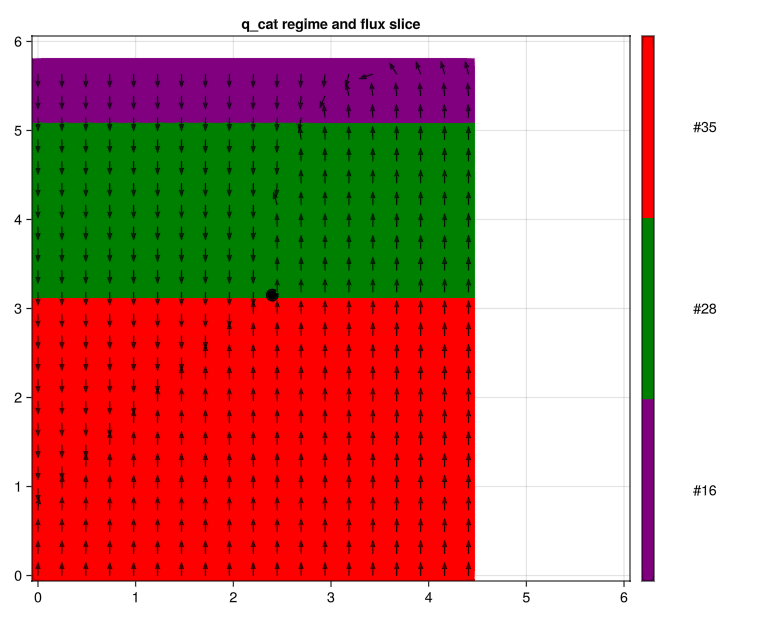

In [ ]:
fig, ax, data = plot_qcat_slice_with_flux(model; wKk=p, ranges=(0,6), n=50, arrow_stride=2)
fig

In [ ]:
get_idx(bnc_rgm_max)

28

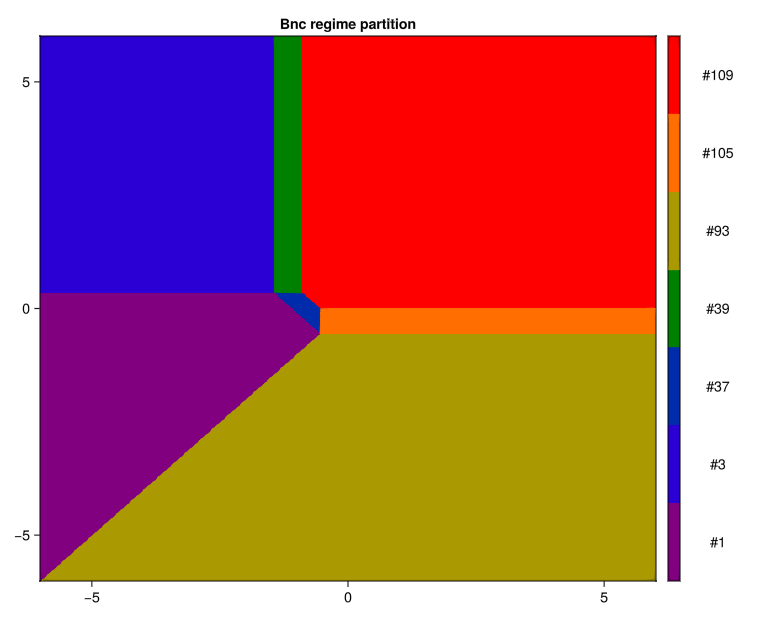

In [ ]:
fig, ax, data = plot_bnc_regime_partition(model; axes=[:tI,:tAtotal], fixed=p, ranges=(-6,6), n=500)
fig

In [ ]:
model2 = let 
    qsym = w_symbol(model)
    xsym = x_symbol(model)
    L = get_Lcat(model)
    N = vcat(model.N, model.catalysis.S * model.catalysis.Π)
    Ksym = vcat(K_symbol(model),:kA2➗kA1,:kB2➗kB1)
    Bnc(N=N,L=L, x_sym=xsym, q_sym=qsym, K_sym=Ksym)
end

----------Binding Network Summary:-------------
Number of species (n): 10
Number of conserved quantities (d): 4
Number of reactions (r): 6
L matrix: sparse([3, 1, 1, 2, 2, 4, 1, 3, 1, 2, 1, 2, 2, 4], [1, 2, 3, 4, 5, 6, 7, 7, 8, 8, 9, 9, 10, 10], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 4, 10)
N matrix: sparse([1, 1, 2, 3, 3, 2, 4, 4, 1, 5, 2, 5, 3, 6, 4, 6], [1, 2, 3, 3, 4, 5, 5, 6, 7, 7, 8, 8, 9, 9, 10, 10], [1, 1, 1, 1, 1, 1, 1, 1, -1, 1, -1, -1, -1, 1, -1, -1], 6, 10)
Direction of binding reactions: backward
Catalysis involved: No
Regimes constructed: No
-----------------------------------------------

In [ ]:
wKk_sym(model)

12-element Vector{Symbolics.Num}:
 tAtotal
 tBtotal
      tI
      tE
     KA1
     KA2
     KB1
     KB2
     kA1
     kA2
     kB1
     kB2

In [ ]:
qK_sym(model2)

10-element Vector{Symbolics.Num}:
  tAtotal
  tBtotal
       tI
       tE
      KA1
      KA2
      KB1
      KB2
 kA2➗kA1
 kB2➗kB1

In [ ]:
p = get_one_inner_point(bnc_rgm_max,rand_line=false, rand_ray=false, extend=4)

12-element Vector{Float64}:
  2.9260714544100037
  5.754498579156193
  0.09764432966381387
 -1.316569232709281
 -1.0739285455899963
  2.9260714544100037
  2.9260714544100037
  0.0
 -3.414213562373095
  0.0
 -2.2426406871192848
  0.0

In [ ]:
modelwKk2model2qK(p)=let 
    p_inner = Float64[]
    for sym in qK_symbol(model2)
        try
            idx = locate_sym_wKk(model, sym)
            push!(p_inner, p[idx])
        catch
            nothing
        end
    end
    kA1 = locate_sym_wKk(model,:kA1)
    kA2 = locate_sym_wKk(model,:kA2)
    kB1 = locate_sym_wKk(model,:kB1)
    kB2 = locate_sym_wKk(model,:kB2)
    push!(p_inner, p[kA2] - p[kA1])
    push!(p_inner, p[kB2] - p[kB1])
    p_inner
end


modelwKk2model2qK (generic function with 1 method)

In [ ]:
p_bind = modelwKk2model2qK(p)

10-element Vector{Float64}:
  2.3
  3.7
  0.9
  1.6
  0.3
  1.5
  2.3
  0.0
  1.7
 -0.3

In [ ]:
perm_bind = assign_regime_qK(model2, p_bind ;input_logspace=true)

4-element Vector{Int64}:
  2
  4
  7
 10

In [ ]:
rgm = get_regime(model2, perm_bind)

BindRegime
  dominant mode: perm=[2, 4, 7, 10]
  nullity: 0
  asymptotic: true

In [ ]:
get_idx(rgm)

4

In [ ]:
show_equilibrium(model2)

6-element Vector{Symbolics.Equation}:
 KA1 ~ (A*I) / C1
 KA2 ~ (Astar*Bstar) / C2
 KB1 ~ (Astar*B) / C3
 KB2 ~ (Bstar*E) / C4
 kA2➗kA1 ~ C1 / C2
 kB2➗kB1 ~ C3 / C4

In [ ]:
show_expression_x(rgm)

10-element Vector{Symbolics.Equation}:
 I ~ (KA1*tI) / tAtotal
 A ~ tAtotal
 Astar ~ (KB1*kB2➗kB1*tE) / tBtotal
 B ~ tBtotal
 Bstar ~ (KA2*tBtotal*tI) / (KB1*kA2➗kA1*kB2➗kB1*tE)
 E ~ (KB1*KB2*kA2➗kA1*kB2➗kB1*(tE^(2//1))) / (KA2*tBtotal*tI)
 C1 ~ tI
 C2 ~ tI / kA2➗kA1
 C3 ~ kB2➗kB1*tE
 C4 ~ tE

In [ ]:
f,ax = SIMO_plot(model2, p_bind, :tI ;method=:homotopy,start=-4,stop=10,observe_x=[:Astar,:C2, :C3])

Using parameters: Dict(:kB2➗kB1 => -0.3, :KB2 => 0.0, :tBtotal => 3.7, :tAtotal => 2.3, :tE => 1.6, :KA2 => 1.5, :KA1 => 0.3, :KB1 => 2.3, :kA2➗kA1 => 1.7)


(Scene(2 children, 0 plots), Axis (14 plots))

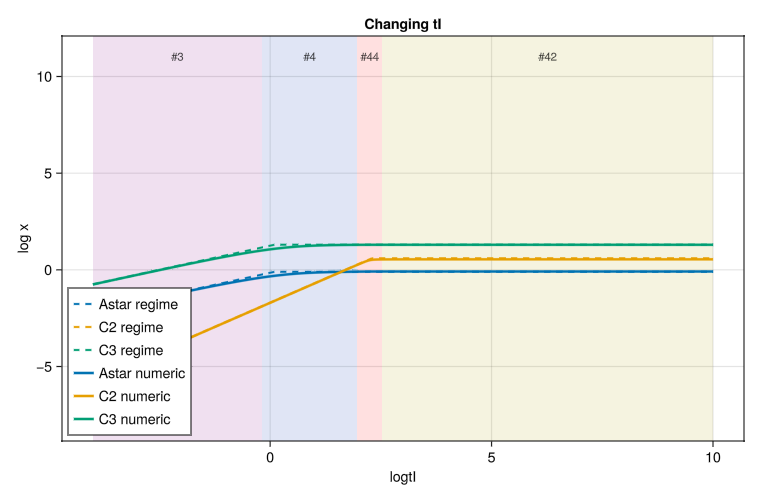

In [ ]:
f

In [ ]:
assign_bnc_regime_wKk(model,p)

36

In [ ]:
get_bnc_regime(model,36) === bnc_rgm_max

true

In [ ]:
show_expression_qK(get_binding_regime(bnc_rgm_max))

10-element Vector{Symbolics.Equation}:
 tAstar ~ C3
 tBstar ~ C4
 tAtotal ~ A
 tBtotal ~ B
 tI ~ C1
 tE ~ C4
 KA1 ~ (A*I) / C1
 KA2 ~ (Astar*Bstar) / C2
 KB1 ~ (Astar*B) / C3
 KB2 ~ (Bstar*E) / C4

In [ ]:
get_H(get_binding_regime(bnc_rgm_max))

10×10 SparseMatrixCSC{Rational{Int64}, Int64} with 6 stored entries:
 ⋅   ⋅  ⋅  ⋅  ⋅   ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅   ⋅  ⋅  ⋅  ⋅   ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅   ⋅  ⋅  ⋅  ⋅   ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅   ⋅  ⋅  ⋅  ⋅   ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅   1  ⋅  ⋅  ⋅  -1  ⋅  ⋅  ⋅  ⋅
 ⋅  -1  ⋅  ⋅  ⋅   1  ⋅  ⋅  ⋅  ⋅
 ⋅   ⋅  ⋅  ⋅  ⋅   ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅   1  ⋅  ⋅  ⋅  -1  ⋅  ⋅  ⋅  ⋅
 ⋅   ⋅  ⋅  ⋅  ⋅   ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅   ⋅  ⋅  ⋅  ⋅   ⋅  ⋅  ⋅  ⋅  ⋅

In [ ]:
findnz(get_H(get_binding_regime(bnc_rgm_max)))

([5, 6, 8, 5, 6, 8], [2, 2, 2, 6, 6, 6], Rational{Int64}[1, -1, 1, -1, 1, -1])

In [ ]:
x_symbol(model)[[5,6,5,6,8]]

5-element Vector{Symbol}:
 :Bstar
 :E
 :Bstar
 :E
 :C2

In [ ]:
qK_symbol(model)[[2,2,2,6,6,6]]

6-element Vector{Symbol}:
 :tBstar
 :tBstar
 :tBstar
 :tE
 :tE
 :tE

In [ ]:
show_cat_dynamics(bnc_rgm_max)

┌ Error: The regime is singular. The expression is not valid.
└ @ BindingAndCatalysis ~/Realizibility_index/BindingAndCatalysis.jl/src/symbolic/symbolic_api.jl:20


6-element Vector{Symbolics.Equation}:
 Differential(t, 1)(tAstar) ~ kA1 + (-kA2*tBstar) / tE
 Differential(t, 1)(tBstar) ~ kB1 - kB2
 Differential(t, 1)(tAtotal) ~ 0
 Differential(t, 1)(tBtotal) ~ 0
 Differential(t, 1)(tI) ~ 0
 Differential(t, 1)(tE) ~ 0

In [ ]:
get_volume(rgm)

Volume(Mean=7.002e-04, STD=3.500e-06, RelError=0.50%)

## Dynamic adaptation and steady-state input response

The helpers below use `log10` coordinates. `p` is the fixed `wKk` vector; only `tI` is replaced by the user-provided input `logtI(t)`.


In [65]:
using BindingAndCatalysis.Polyhedra

function coordinate_bounds_in_polyhedron(polyhedron, index::Integer, parameters; atol=1e-9)
    x = Float64.(parameters)
    n = length(x)

    index < 1 && throw(ArgumentError("index must be >= 1"))
    index > n && throw(ArgumentError("index must be <= length(parameters)"))

    lower = -Inf
    upper = Inf
    inside = true

    for hs in halfspaces(polyhedron)
        a = Float64.(hs.a)
        β = Float64(hs.β)

        length(a) == n || throw(DimensionMismatch(
            "HalfSpace dimension $(length(a)) does not match parameter dimension $n"
        ))

        lhs = dot(a, x)

        if lhs > β + atol
            inside = false
        end

        ai = a[index]

        # Constraint:
        #     a ⋅ x ≤ β
        #
        # Split x[index] from the rest:
        #     ai * x[index] + rest ≤ β
        #
        # Therefore:
        #     ai * x[index] ≤ β - rest
        rest = lhs - ai * x[index]
        rhs = β - rest

        if abs(ai) ≤ atol
            # This inequality does not constrain x[index].
            # If rest > β, then no value of x[index] can satisfy it.
            if rest > β + atol
                return (; inside=false, feasible=false, lower=NaN, upper=NaN)
            end
        elseif ai > 0
            # ai * x[index] ≤ rhs
            # x[index] ≤ rhs / ai
            upper = min(upper, rhs / ai)
        else
            # ai * x[index] ≤ rhs, ai < 0
            # x[index] ≥ rhs / ai
            lower = max(lower, rhs / ai)
        end
    end

    feasible = lower ≤ upper + atol

    return (;
        inside,
        feasible,
        lower,
        upper,
        current=x[index],
    )
end

coordinate_bounds_in_polyhedron (generic function with 1 method)

In [ ]:
rgms_singluarbinding = let
    rgms_singluarbinding = Any[]
    for (rgm,v) in rgm_Astar
        if is_singular(get_binding_regime(rgm))
            push!(rgms_singluarbinding, rgm)
        end
    end
    rgms_singluarbinding
end

4-element Vector{Any}:
 BncRegime(bind=[8, 8, 2, 4, 1, 10], cat=[1, 3, 2, 4], ss=([8, 8, 2, 4, 1, 10], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[8, 8, 2, 4, 7, 10], cat=[1, 3, 2, 4], ss=([8, 8, 2, 4, 7, 10], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[8, 10, 2, 4, 1, 10], cat=[1, 3, 2, 4], ss=([8, 10, 2, 4, 1, 10], [1, 3, 2, 4]), nullity=0, asymptotic=true)
 BncRegime(bind=[8, 10, 2, 4, 7, 10], cat=[1, 3, 2, 4], ss=([8, 10, 2, 4, 7, 10], [1, 3, 2, 4]), nullity=0, asymptotic=true)

In [ ]:
findmax(get_volumes([rgms_singluarbinding...]))

(Volume(Mean=3.865e-04, STD=1.932e-06, RelError=0.50%), 2)

In [ ]:
bnc_rgm_max = rgms_singluarbinding[findmax(get_volumes([rgms_singluarbinding...]))[2]]

BncRegime
  dominant mode: bind=[8, 8, 2, 4, 7, 10], cat=[1, 3, 2, 4], ss=([8, 8, 2, 4, 7, 10], [1, 3, 2, 4])
  nullity: 0
  asymptotic: true

In [76]:
i=1

1

In [94]:
i

18

BindRegime
  dominant mode: perm=[9, 10, 2, 10, 1, 6]
  nullity: 1
  asymptotic: true

┌ Error: M is still singular after maximum perturbation attempts.
└ @ BindingAndCatalysis ~/Realizibility_index/BindingAndCatalysis.jl/src/qK_x_mapping.jl:648
┌ Error: M is still singular after maximum perturbation attempts.
└ @ BindingAndCatalysis ~/Realizibility_index/BindingAndCatalysis.jl/src/qK_x_mapping.jl:648


M = sparse([5, 7, 3, 7, 1, 3, 8, 9, 4, 9, 2, 4, 8, 10, 6, 10, 3, 5, 7, 1, 2, 3, 4, 8, 1, 3, 4, 9, 2, 4, 6, 10], [1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5, 5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 9, 10, 10, 10, 10], [0.9996848587761167, 1.0, 0.9968782095023552, 1.0, 0.0, 2.220446049250313e-14, 1.0, 1.0, 3.6566953259512655e190, 1.0, 0.0008058562225979789, 0.002000486059802496, 1.0, 1.0, 1.020404492071494, 1.0, 3.151412238830051e-5, 0.0003151412238830051, -1.0, 0.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, -1.0, 0.08222993095027226, 0.20413049617488183, 0.0020413049617488193, -1.0], 10, 10)


┌ Error: M is still singular after maximum perturbation attempts.
└ @ BindingAndCatalysis ~/Realizibility_index/BindingAndCatalysis.jl/src/qK_x_mapping.jl:648
┌ Error: M is still singular after maximum perturbation attempts.
└ @ BindingAndCatalysis ~/Realizibility_index/BindingAndCatalysis.jl/src/qK_x_mapping.jl:648


M = sparse([5, 7, 3, 7, 1, 3, 8, 9, 4, 9, 2, 4, 8, 10, 6, 10, 3, 5, 7, 1, 2, 3, 4, 8, 1, 3, 4, 9, 2, 4, 6, 10], [1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5, 5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 9, 10, 10, 10, 10], [0.9891516437486833, 1.0, 3.663728588075303e14, 1.0, 0.0, 2.220446049250313e-14, 1.0, 1.0, 2.220446049250313e-14, 1.0, 4.598691171898183e-5, 4.598690873424518e-5, 1.0, 1.0, 1.0045786229282248, 1.0, 1.1909466898359179e10, 1.1909466898359178e11, -1.0, 0.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, -1.0, 0.7225750370833519, 0.7225749901853085, 0.007225749901853088, -1.0], 10, 10)
M = sparse([5, 7, 3, 7, 1, 3, 8, 9, 4, 9, 2, 4, 8, 10, 6, 10, 3, 5, 7, 1, 2, 3, 4, 8, 1, 3, 4, 9, 2, 4, 6, 10], [1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5, 5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 9, 10, 10, 10, 10], [0.9503714717132274, 1.0, 1.0e20, 1.0, 0.0, 2.220446049250313e-14, 1.0, 1.0, 2.220446049250313e-14, 1.0, 9.999999375887786e19, 1.0e20, 1.0, 1.0, 0.21535897144651694, 1.0, 1.0e20, 1.0e21, -1.0, 0.0, 

...

M = sparse([5, 7, 3, 7, 1, 3, 8, 9, 4, 9, 2, 4, 8, 10, 6, 10, 3, 5, 7, 1, 2, 3, 4, 8, 1, 3, 4, 9, 2, 4, 6, 10], [1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5, 5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 9, 10, 10, 10, 10], [0.8983628399197529, 1.0, 1.0e20, 1.0, 0.0, 2.220446049250313e-14, 1.0, 1.0, 2.220446049250313e-14, 1.0, 1.0000001020708725e20, 1.0e20, 1.0, 1.0, 2.2453456047964995, 1.0, 1.0e20, 1.0e21, -1.0, 0.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, -1.0, 7.868861105526564e15, 7.868860302345096e15, 7.868860302345097e13, -1.0], 10, 10)
M = sparse([5, 7, 3, 7, 1, 3, 8, 9, 4, 9, 2, 4, 8, 10, 6, 10, 3, 5, 7, 1, 2, 3, 4, 8, 1, 3, 4, 9, 2, 4, 6, 10], [1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5, 5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 9, 10, 10, 10, 10], [1.7374209826120413, 1.0, 0.0, 1.0, 3.199670338724172e22, 1.0e20, 1.0, 1.0, 2.220446049250313e-14, 1.0, 1.0000001020601315e20, 1.0e20, 1.0, 1.0, 1.0894777215321314, 1.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, -1.0, 1.0000001020601315

┌ Error: M is still singular after maximum perturbation attempts.
└ @ BindingAndCatalysis ~/Realizibility_index/BindingAndCatalysis.jl/src/qK_x_mapping.jl:648
┌ Error: M is still singular after maximum perturbation attempts.
└ @ BindingAndCatalysis ~/Realizibility_index/BindingAndCatalysis.jl/src/qK_x_mapping.jl:648


M = sparse([5, 7, 3, 7, 1, 3, 8, 9, 4, 9, 2, 4, 8, 10, 6, 10, 3, 5, 7, 1, 2, 3, 4, 8, 1, 3, 4, 9, 2, 4, 6, 10], [1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5, 5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 9, 10, 10, 10, 10], [0.9918208381458133, 1.0, 7.641991302671815e10, 1.0, 0.0, 2.220446049250313e-14, 1.0, 1.0, 2.220446049250313e-14, 1.0, 2650.8397985763268, 2650.839550202119, 1.0, 1.0, 0.8844900027608334, 1.0, 2.3938233306879327e6, 2.3938233306879327e7, -1.0, 0.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, -1.0, 155556.00327266243, 155555.98869762148, 1555.5598869762148, -1.0], 10, 10)
M = sparse([5, 7, 3, 7, 1, 3, 8, 9, 4, 9, 2, 4, 8, 10, 6, 10, 3, 5, 7, 1, 2, 3, 4, 8, 1, 3, 4, 9, 2, 4, 6, 10], [1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5, 5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 9, 10, 10, 10, 10], [0.9996848728724954, 1.0, 0.996833604733866, 1.0, 0.0, 2.220446049250313e-14, 1.0, 1.0, 2.220446049250313e-14, 1.0, 0.009835650752054639, 0.009893468017304445, 1.0, 1.0, 0.990203944078792, 1.0, 3.15127127505

Excessive output truncated after 524741 bytes.┌ Error: M is still singular after maximum perturbation attempts.
└ @ BindingAndCatalysis ~/Realizibility_index/BindingAndCatalysis.jl/src/qK_x_mapping.jl:648
┌ Error: M is still singular after maximum perturbation attempts.
└ @ BindingAndCatalysis ~/Realizibility_index/BindingAndCatalysis.jl/src/qK_x_mapping.jl:648


M = sparse([5, 7, 3, 7, 1, 3, 8, 9, 4, 9, 2, 4, 8, 10, 6, 10, 3, 5, 7, 1, 2, 3, 4, 8, 1, 3, 4, 9, 2, 4, 6, 10], [1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5, 5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 9, 10, 10, 10, 10], [1.0064518652233947, 1.0, 5.045339087289538e-10, 1.0, 0.0, 2.220446049250313e-14, 1.0, 1.0, 2.220446049250313e-14, 1.0, 9.2965771173945e-5, 9.296575246797831e-5, 1.0, 1.0, 0.8696715980380012, 1.0, 1.6033074140070506e-14, 1.6033074140070506e-13, -1.0, 0.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, -1.0, 3684.137567138539, 3684.1368258403845, 36.84136825840384, -1.0], 10, 10)
M = sparse([5, 7, 3, 7, 1, 3, 8, 9, 4, 9, 2, 4, 8, 10, 6, 10, 3, 5, 7, 1, 2, 3, 4, 8, 1, 3, 4, 9, 2, 4, 6, 10], [1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5, 5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 9, 10, 10, 10, 10], [0.9347320712187359, 1.0, 1.0e20, 1.0, 0.0, 2.220446049250313e-14, 1.0, 1.0, 2.220446049250313e-14, 1.0, 7.798052902201716e-24, 7.798052251978198e-24, 1.0, 1.0, 0.38677455780162456, 1.0, 1.0e20, 1.0e21

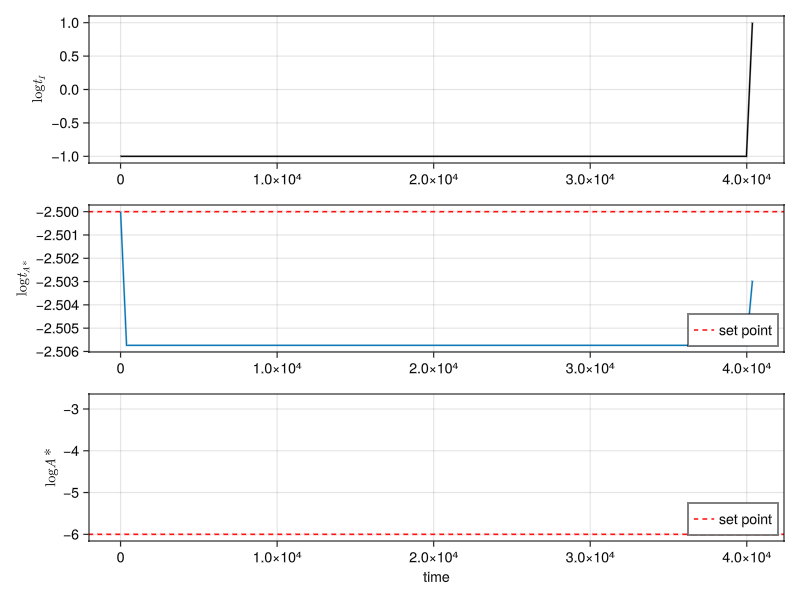

In [96]:
bnc_rgm_max =singular_rgm[i]
poly = get_polyhedron(bnc_rgm_max)
p = get_one_inner_point(poly,rand_line=false, rand_ray=false, extend=5)
p = round.(p, digits=1)

#===========================================================================#
display(get_binding_regime(bnc_rgm_max))
#===========================================================================#

logqcat0 = let 
    F,F0 = get_qcat_F_F0(bnc_rgm_max)
    Vector{Float64}(F * p .+ F0)
end

logx0 = let 
    H,H0 = get_H_H0(bnc_rgm_max)
    Vector{Float64}(H * p .+ H0)
end


tAstar0 = logqcat0[1] 
logqcat0 .+= eps()

Astar0 = logx0[locate_sym_x(model, :Astar)]

rlt = coordinate_bounds_in_polyhedron(poly, locate_sym_wKk(model, :tI), p)
# Dynamic adaptation: step tI up and then down from the current p.

stop1 = 40000.0
stop2 = stop1 + 50000.0
stop3 = stop2 + 50000.0
endt = stop3 + 50000.0
tI0 = p[locate_sym_wKk(model, :tI)]
logtI_input(t) = t < stop1 ? tI0-1 : t < stop2 ? tI0+1 : t< stop3 ? tI0+2  : tI0+3

logqcat0_dense = Vector{Float64}(logqcat0)

savegrid = range(0.0, endt, length=500)
tstops = [stop1, stop2, stop3]

dyn_Astar = simulate_adaptation(
    model;
    p=p,
    logtI=logtI_input,
    tspan=(0.0, endt),
    observe=:Astar,
    logqcat0=logqcat0_dense,
    # method=:homotopy,
    saveat=savegrid,
    tstops=tstops,
    maxiters=300_000,
)

tAstar_idx = locate_sym_qcat(model, :tAstar)
dyn_tAstar = merge(dyn_Astar, (;
    logobserve=vec(dyn_Astar.logqcat[tAstar_idx, :]),
    observe=:tAstar,
))

fig = Figure(size=(800, 600))

ax2 = Axis(fig[1, 1],  ylabel=L"\log{t_I}")
lines!(ax2, dyn_Astar.t, dyn_Astar.logtI; color=:black)

ax1 = Axis(fig[2, 1], ylabel=L"\log{t_{A*}}")
# lines!(ax1, dyn_Astar.t, dyn_Astar.logobserve; label="Astar")
lines!(ax1, dyn_tAstar.t, dyn_tAstar.logobserve;)
hlines!(ax1, tAstar0, color=:red, linestyle=:dash, label="set point")
axislegend(ax1, position=:rb)

ax3 = Axis(fig[3, 1], xlabel="time", ylabel=L"\log{A*}")
# lines!(ax1, dyn_Astar.t, dyn_Astar.logobserve; label="Astar")
lines!(ax3, dyn_Astar.t, dyn_Astar.logobserve; )
hlines!(ax3, Astar0, color=:red, linestyle=:dash,label="set point")
axislegend(ax3, position=:rb)

i+=1
fig


In [ ]:
p_bind = modelwKk2model2qK(p)

10-element Vector{Float64}:
  6.4
  7.5
  2.9
  0.4
  1.4
 -1.6
  7.5
  0.0
 -1.0
  0.0

In [ ]:
p_bind[locate_sym_qK(model2, :tI)] -=1

2.9000000000000004

In [ ]:
qK2x(model2, p_bind;input_logspace=true,output_logspace=true,method=:homotopy)[locate_sym_x(model2, :Astar)]

0.3947418907022582

In [ ]:
Astar0

0.40000000000000036

In [ ]:
rlt = coordinate_bounds_in_polyhedron(poly, locate_sym_wKk(model, :tI), p)

(inside = true, feasible = true, lower = 0.9999999999999996, upper = 5.4, current = 2.9)

In [ ]:
save("NFBLB_dynamics.png", fig,px_per_unit=3)

In [123]:
ps = get_polyhedron.(all_rgm)

26-element Vector{CDDLib.Polyhedron{Float64}}:
 HalfSpace([1.0, 1.0, 1.0, -1.0, -1.0, 0.0, -1.0, 0.0, 1.0, -1.0, 1.0, -1.0], 0.0) ∩ HalfSpace([0.0, 1.0, 0.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0.0) ∩ HalfSpace([0.0, -1.0, 0.0, 1.0, 0.0, -1.0, 1.0, 0.0, 0.0, 0.0, -1.0, 1.0], 0.0) ∩ HalfSpace([-1.0, -1.0, -1.0, 2.0, 1.0, -1.0, 1.0, 0.0, -1.0, 1.0, -1.0, 1.0], 0.0) ∩ HalfSpace([-1.0, -1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, -1.0, 1.0], 0.0) ∩ HalfSpace([0.0, 0.0, 1.0, 0.0, -1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0.0) ∩ HalfSpace([0.0, 0.0, 1.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0, -1.0, 0.0, 0.0], 0.0) ∩ HalfSpace([-1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0, 1.0], 0.0) ∩ HalfSpace([1.0, 0.0, 1.0, -1.0, -1.0, 1.0, -1.0, 0.0, 1.0, -1.0, 1.0, -1.0], 0.0) ∩ HalfSpace([1.0, -1.0, 1.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0, -1.0, 0.0, 0.0], 0.0) ∩ HalfSpace([0.0, -1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0, 1.0], 0.0) ∩ HalfSpace([0.0, -1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0

In [ ]:
using BindingAndCatalysis.

LoadError: UndefVarError: `statistics` not defined in `BindingAndCatalysis`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name also exists in DelaunayTriangulation.

In [126]:
wKk_sym(model)

12-element Vector{Symbolics.Num}:
 tAtotal
 tBtotal
      tI
      tE
     KA1
     KA2
     KB1
     KB2
     kA1
     kA2
     kB1
     kB2

In [10]:
ps = get_polyhedron.(all_rgm)

26-element Vector{CDDLib.Polyhedron{Float64}}:
 HalfSpace([1.0, 1.0, 1.0, -1.0, -1.0, 0.0, -1.0, 0.0, 1.0, -1.0, 1.0, -1.0], 0.0) ∩ HalfSpace([0.0, 1.0, 0.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0.0) ∩ HalfSpace([0.0, -1.0, 0.0, 1.0, 0.0, -1.0, 1.0, 0.0, 0.0, 0.0, -1.0, 1.0], 0.0) ∩ HalfSpace([-1.0, -1.0, -1.0, 2.0, 1.0, -1.0, 1.0, 0.0, -1.0, 1.0, -1.0, 1.0], 0.0) ∩ HalfSpace([-1.0, -1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, -1.0, 1.0], 0.0) ∩ HalfSpace([0.0, 0.0, 1.0, 0.0, -1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0.0) ∩ HalfSpace([0.0, 0.0, 1.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0, -1.0, 0.0, 0.0], 0.0) ∩ HalfSpace([-1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0, 1.0], 0.0) ∩ HalfSpace([1.0, 0.0, 1.0, -1.0, -1.0, 1.0, -1.0, 0.0, 1.0, -1.0, 1.0, -1.0], 0.0) ∩ HalfSpace([1.0, -1.0, 1.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0, -1.0, 0.0, 0.0], 0.0) ∩ HalfSpace([0.0, -1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0, 1.0], 0.0) ∩ HalfSpace([0.0, -1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0

In [11]:
v_polys = let 
    rgk = (-3.,4.)
    rgK = (-3.,4.)
    rgw = (0.,4.)
    lower = [repeat([rgw[1]],4); repeat([rgK[1]],4); repeat([rgk[1]],4)]
    upper = [repeat([rgw[2]],4); repeat([rgK[2]],4); repeat([rgk[2]],4)]
    calc_volume(ps; sampler=:uniform_box, log_lower=lower, log_upper=upper)
end

[ Info: Number of polyhedra to calc volume: 26
[ Info: All regimes converged after 967400000 samples.


26-element Vector{BindingAndCatalysis.Volume}:
 Volume(Mean=2.437e+05, STD=1.219e+03, RelError=0.50%)
 Volume(Mean=5.386e+05, STD=2.693e+03, RelError=0.50%)
 Volume(Mean=5.752e+05, STD=2.875e+03, RelError=0.50%)
 Volume(Mean=1.282e+06, STD=6.408e+03, RelError=0.50%)
 Volume(Mean=1.563e+06, STD=7.812e+03, RelError=0.50%)
 Volume(Mean=3.893e+06, STD=1.946e+04, RelError=0.50%)
 Volume(Mean=2.344e+05, STD=1.172e+03, RelError=0.50%)
 Volume(Mean=1.368e+06, STD=6.838e+03, RelError=0.50%)
 Volume(Mean=9.243e+05, STD=4.621e+03, RelError=0.50%)
 Volume(Mean=2.224e+06, STD=1.112e+04, RelError=0.50%)
 Volume(Mean=2.696e+06, STD=1.348e+04, RelError=0.50%)
 Volume(Mean=5.782e+06, STD=2.890e+04, RelError=0.50%)
 Volume(Mean=3.142e+06, STD=1.570e+04, RelError=0.50%)
 Volume(Mean=6.876e+06, STD=3.434e+04, RelError=0.50%)
 Volume(Mean=1.664e+06, STD=8.322e+03, RelError=0.50%)
 Volume(Mean=4.666e+06, STD=2.332e+04, RelError=0.50%)
 Volume(Mean=3.003e+06, STD=1.501e+04, RelError=0.50%)
 Volume(Mean=1.062

In [14]:
V = zero(BindingAndCatalysis.Volume)
for (v,rgm) in zip(v_polys, all_rgm)
    if rgm in good_rgm_tAstar 
        V += v
    end
end

In [15]:
V

Volume(Mean=6.381e+07, STD=9.231e+04, RelError=0.14%)

In [12]:
V = zero(BindingAndCatalysis.Volume)
for (v,rgm) in zip(v_polys, all_rgm)
    if rgm in good_rgm_Astar 
        V += v
    end
end

In [17]:
model3 = Bnc(
    N = [1 1 -1],
    x_sym = [:E, :S, :C],
    q_sym = [:tE, :tS],
    K_sym = [:K]
)

----------Binding Network Summary:-------------
Number of species (n): 3
Number of conserved quantities (d): 2
Number of reactions (r): 1
L matrix: sparse([1, 2, 1, 2], [1, 2, 3, 3], [1, 1, 1, 1], 2, 3)
N matrix: sparse([1, 1, 1], [1, 2, 3], [1, 1, -1], 1, 3)
Direction of binding reactions: backward
Catalysis involved: No
Regimes constructed: No
-----------------------------------------------

In [13]:
V

Volume(Mean=3.134e+07, STD=5.598e+04, RelError=0.18%)

In [25]:
show_expression_x(model3,3)

3-element Vector{Symbolics.Equation}:
 E ~ (K*tE) / tS
 S ~ tS
 C ~ tE

In [26]:
f,ax = draw_graph(model3)

[ Info: All regimes converged after 400000 samples.


(Scene(1 children, 0 plots), Axis (2 plots), Plot{GraphMakie.graphplot, Tuple{Graphs.SimpleGraphs.SimpleDiGraph{Int64}}})

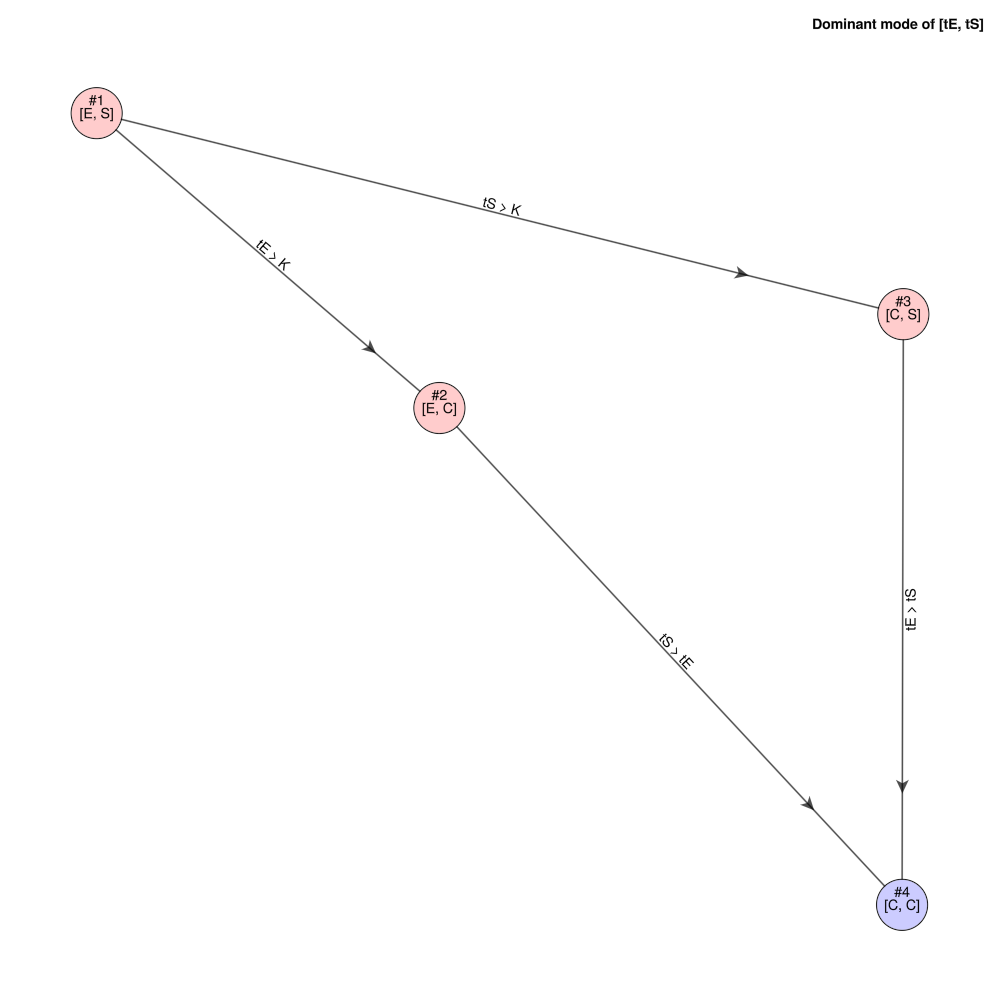

In [27]:
f